# 512. EPI & Volatility Forecasting

**Objective**: Test whether the Emotional Polarity Index (EPI) from YouTube financial commentary can predict asset return volatility.

**Hypothesis**: Emotional intensity in financial YouTube content may better predict market volatility than returns themselves, as heightened emotions often precede periods of market uncertainty.

## Approach
1. **Volatility Measures**: Realized volatility, absolute returns, squared returns
2. **EPI Variables**: Contemporaneous and lagged EPI (1-5 days)
3. **Models**: 
   - ARX models for volatility forecasting
   - GARCH-X models with EPI in variance equation
4. **Evaluation**: RMSE, MAE, directional accuracy for volatility changes

In [1]:
# ============================================================
# 1. Imports and Configuration
# ============================================================
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.stattools import grangercausalitytests, adfuller
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Try to import arch for GARCH models
try:
    from arch import arch_model
    ARCH_AVAILABLE = True
    print("✓ arch package available for GARCH models")
except ImportError:
    ARCH_AVAILABLE = False
    print("⚠ arch package not installed. Run: pip install arch")
    print("  GARCH models will be skipped.")

# File paths
DATA_DIR = "data"
EPI_FILE = f"{DATA_DIR}/epi_data.json"
FINANCIAL_PANEL_FILE = f"{DATA_DIR}/financial_returns_and_controls.parquet"

# Date range
START_DATE = "2025-01-01"
END_DATE = "2025-05-31"

print(f"\nAnalysis period: {START_DATE} to {END_DATE}")

✓ arch package available for GARCH models

Analysis period: 2025-01-01 to 2025-05-31


## 2. Load and Prepare Data

In [2]:
# ============================================================
# 2a. Load Financial Panel Data
# ============================================================
panel = pd.read_parquet(FINANCIAL_PANEL_FILE)

# Check if 'date' is a column or already the index
if "date" in panel.columns:
    panel["date"] = pd.to_datetime(panel["date"])
    panel = panel.set_index("date")
elif panel.index.name == "date" or isinstance(panel.index, pd.DatetimeIndex):
    panel.index = pd.to_datetime(panel.index)
    panel.index.name = "date"
else:
    # Try to reset and use first column as date
    panel = panel.reset_index()
    date_col = panel.columns[0]
    panel[date_col] = pd.to_datetime(panel[date_col])
    panel = panel.set_index(date_col)
    panel.index.name = "date"

panel = panel.sort_index()
panel = panel[(panel.index >= START_DATE) & (panel.index <= END_DATE)]

print(f"Financial panel shape: {panel.shape}")
print(f"Date range: {panel.index.min()} to {panel.index.max()}")
print(f"\nColumns: {panel.columns.tolist()}")

Financial panel shape: (108, 30)
Date range: 2025-01-01 00:00:00 to 2025-05-30 00:00:00

Columns: ['r_btc', 'r_gold', 'r_spx', 'dln_eurusd', 'dln_usdcny', 'dln_oil', 'dy10', 'ei_creator', 'ei_community', 'epi', 'epi_weighted', 'epi_', 'epi_Environmental and Infrastructure', 'epi_Labor and Workforce', 'epi_Health and Social Welfare', 'epi_Legal and Regulatory Framework', 'epi_Education and Knowledge', 'epi_Psychological and Emotional Aspects', 'epi_Leadership and Governance', 'epi_Economic and Financial Matters', 'epi_Disaster and Resilience', 'epi_Security and Conflict', 'epi_Disputes and Opinions', 'epi_Miscellaneous and Other', 'epi_Sports and Recreation', 'epi_Power and Influence Dynamics', 'epi_Social and Cultural Aspects', 'epi_Quality of Life and Standards', 'epi_Trust, Credibility, and Communication', 'epi_Conspiracy and Historical Events']


In [3]:
# ============================================================
# 2b. Load EPI Data
# ============================================================
df_epi = pd.read_json(EPI_FILE)

# Check if 'date' is a column or already the index
if "date" in df_epi.columns:
    df_epi["date"] = pd.to_datetime(df_epi["date"])
    df_epi = df_epi.set_index("date")
elif df_epi.index.name == "date" or isinstance(df_epi.index, pd.DatetimeIndex):
    df_epi.index = pd.to_datetime(df_epi.index)
    df_epi.index.name = "date"

df_epi = df_epi.sort_index()
df_epi = df_epi[(df_epi.index >= START_DATE) & (df_epi.index <= END_DATE)]

print(f"EPI data shape: {df_epi.shape}")
print(f"EPI columns: {df_epi.columns.tolist()}")

EPI data shape: (148, 23)
EPI columns: ['ei_creator', 'ei_community', 'epi', 'epi_weighted', 'epi_', 'epi_Environmental and Infrastructure', 'epi_Labor and Workforce', 'epi_Health and Social Welfare', 'epi_Legal and Regulatory Framework', 'epi_Education and Knowledge', 'epi_Psychological and Emotional Aspects', 'epi_Leadership and Governance', 'epi_Economic and Financial Matters', 'epi_Disaster and Resilience', 'epi_Security and Conflict', 'epi_Disputes and Opinions', 'epi_Miscellaneous and Other', 'epi_Sports and Recreation', 'epi_Power and Influence Dynamics', 'epi_Social and Cultural Aspects', 'epi_Quality of Life and Standards', 'epi_Trust, Credibility, and Communication', 'epi_Conspiracy and Historical Events']


In [4]:
# ============================================================
# 2c. Merge Data and Create Volatility Measures
# ============================================================

# Check if EPI columns already exist in panel
if "epi" in panel.columns and "epi_weighted" in panel.columns:
    # EPI already in panel, use it directly
    data = panel.copy()
    print("EPI columns already present in financial panel")
else:
    # Merge panel with EPI
    data = panel.join(df_epi[["epi", "epi_weighted"]], how="inner")
    print("Merged EPI data with financial panel")

# Define asset return columns
assets = ["r_btc", "r_gold", "r_spx"]

# Create volatility measures for each asset
for asset in assets:
    # Absolute returns (proxy for volatility)
    data[f"{asset}_abs"] = data[asset].abs()
    
    # Squared returns (another proxy)
    data[f"{asset}_sq"] = data[asset] ** 2
    
    # Rolling realized volatility (5-day window)
    data[f"{asset}_rvol5"] = data[asset].rolling(window=5).std()
    
    # Rolling realized volatility (10-day window)
    data[f"{asset}_rvol10"] = data[asset].rolling(window=10).std()

# Create lagged EPI variables
for lag in range(1, 6):
    data[f"epi_l{lag}"] = data["epi"].shift(lag)
    data[f"epi_weighted_l{lag}"] = data["epi_weighted"].shift(lag)

# Create lagged volatility for AR component
for asset in assets:
    data[f"{asset}_abs_l1"] = data[f"{asset}_abs"].shift(1)
    data[f"{asset}_sq_l1"] = data[f"{asset}_sq"].shift(1)
    data[f"{asset}_rvol5_l1"] = data[f"{asset}_rvol5"].shift(1)

# Drop NaN rows
data = data.dropna()

print(f"\nMerged data shape: {data.shape}")
print(f"Observations: {len(data)}")
print(f"\nVolatility measures created:")
vol_cols = [c for c in data.columns if '_abs' in c or '_sq' in c or '_rvol' in c]
print(vol_cols[:12])  # Show first 12

EPI columns already present in financial panel

Merged data shape: (99, 61)
Observations: 99

Volatility measures created:
['r_btc_abs', 'r_btc_sq', 'r_btc_rvol5', 'r_btc_rvol10', 'r_gold_abs', 'r_gold_sq', 'r_gold_rvol5', 'r_gold_rvol10', 'r_spx_abs', 'r_spx_sq', 'r_spx_rvol5', 'r_spx_rvol10']


## 3. Descriptive Statistics: Volatility Measures

In [5]:
# ============================================================
# 3a. Summary Statistics for Volatility Measures
# ============================================================

vol_summary = []
for asset in assets:
    for vol_type in ["abs", "sq", "rvol5"]:
        col = f"{asset}_{vol_type}"
        if col in data.columns:
            vol_summary.append({
                "Asset": asset,
                "Vol Type": vol_type,
                "Mean": data[col].mean(),
                "Std": data[col].std(),
                "Min": data[col].min(),
                "Max": data[col].max(),
                "Skew": data[col].skew(),
                "Kurt": data[col].kurtosis()
            })

vol_summary_df = pd.DataFrame(vol_summary)
print("Volatility Measures Summary Statistics:")
display(vol_summary_df.round(5))

Volatility Measures Summary Statistics:


,Asset,Vol Type,Mean,Std,Min,Max,Skew,Kurt
0,r_btc,abs,0.02072,0.01877,0.00023,0.09944,1.46104,2.78011
1,r_btc,sq,0.00078,0.00140,0.00000,0.00989,3.91352,20.15335
2,r_btc,rvol5,0.02565,0.01250,0.00564,0.06142,1.15106,1.40685
3,r_gold,abs,0.01035,0.00915,0.00000,0.03730,1.09566,0.54013
4,r_gold,sq,0.00019,0.00029,0.00000,0.00139,2.23861,4.73417
5,r_gold,rvol5,0.01241,0.00625,0.00282,0.02747,0.66134,-0.53549
6,r_spx,abs,0.01026,0.01302,0.00000,0.09089,3.49842,16.78510
7,r_spx,sq,0.00027,0.00094,0.00000,0.00826,6.98384,54.93421
8,r_spx,rvol5,0.01312,0.01078,0.00276,0.06016,2.73381,8.00913


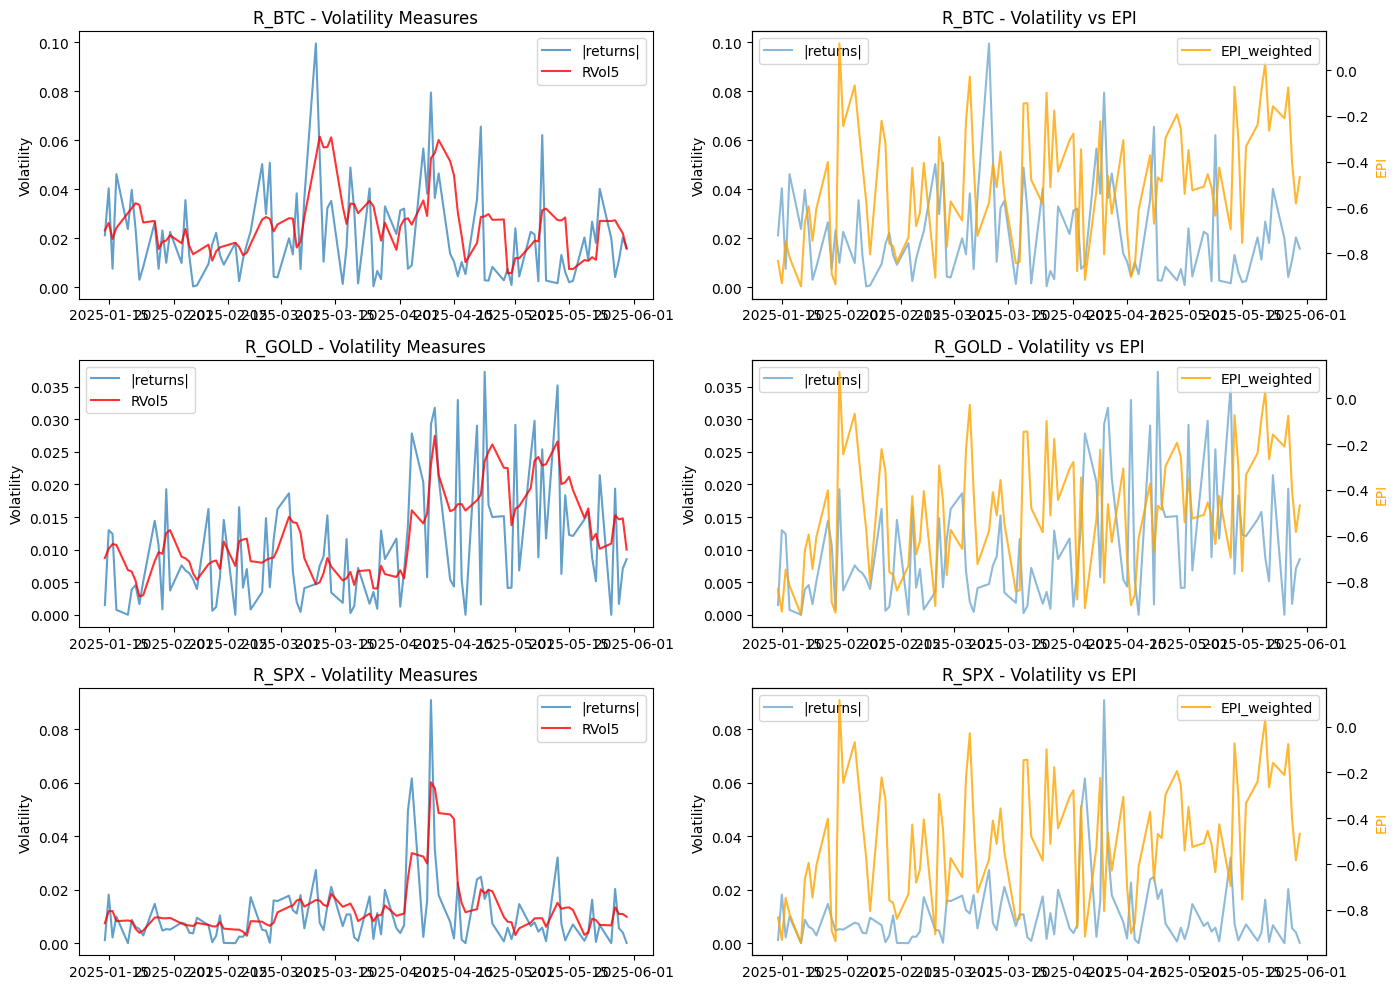

In [6]:
# ============================================================
# 3b. Visualize Volatility Time Series
# ============================================================

fig, axes = plt.subplots(3, 2, figsize=(14, 10))

for i, asset in enumerate(assets):
    # Absolute returns
    axes[i, 0].plot(data.index, data[f"{asset}_abs"], alpha=0.7, label="|returns|")
    axes[i, 0].plot(data.index, data[f"{asset}_rvol5"], color='red', alpha=0.8, label="RVol5")
    axes[i, 0].set_title(f"{asset.upper()} - Volatility Measures")
    axes[i, 0].legend()
    axes[i, 0].set_ylabel("Volatility")
    
    # EPI overlay
    ax2 = axes[i, 1].twinx()
    axes[i, 1].plot(data.index, data[f"{asset}_abs"], alpha=0.5, label="|returns|")
    ax2.plot(data.index, data["epi_weighted"], color='orange', alpha=0.8, label="EPI_weighted")
    axes[i, 1].set_title(f"{asset.upper()} - Volatility vs EPI")
    axes[i, 1].set_ylabel("Volatility")
    ax2.set_ylabel("EPI", color='orange')
    axes[i, 1].legend(loc='upper left')
    ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

## 4. EPI-Volatility Correlation Analysis

In [7]:
# ============================================================
# 4a. Correlation: EPI vs Volatility Measures
# ============================================================

print("="*80)
print("CORRELATION: EPI vs VOLATILITY MEASURES")
print("="*80)
print("Testing if emotional intensity correlates with market volatility\n")

corr_results = []

for asset in assets:
    for vol_type in ["abs", "sq", "rvol5"]:
        vol_col = f"{asset}_{vol_type}"
        
        # Contemporaneous correlation
        for epi_var in ["epi", "epi_weighted"]:
            corr = data[vol_col].corr(data[epi_var])
            corr_results.append({
                "Asset": asset,
                "Vol Type": vol_type,
                "EPI Variable": epi_var,
                "Lag": 0,
                "Correlation": corr
            })
            
            # Lagged correlations (EPI leads volatility)
            for lag in range(1, 6):
                epi_lag_col = f"{epi_var}_l{lag}"
                if epi_lag_col in data.columns:
                    corr_lag = data[vol_col].corr(data[epi_lag_col])
                    corr_results.append({
                        "Asset": asset,
                        "Vol Type": vol_type,
                        "EPI Variable": epi_var,
                        "Lag": lag,
                        "Correlation": corr_lag
                    })

corr_df = pd.DataFrame(corr_results)

# Display pivot table for each asset
for asset in assets:
    print(f"\n{asset.upper()} - EPI-Volatility Correlations:")
    subset = corr_df[(corr_df["Asset"] == asset) & (corr_df["Vol Type"] == "abs")]
    pivot = subset.pivot(index="EPI Variable", columns="Lag", values="Correlation").round(3)
    display(pivot)

CORRELATION: EPI vs VOLATILITY MEASURES
Testing if emotional intensity correlates with market volatility


R_BTC - EPI-Volatility Correlations:


Lag,0,1,2,3,4,5
EPI Variable,,,,,,
epi,-0.064,0.005,0.011,-0.134,-0.055,-0.112
epi_weighted,-0.064,-0.033,-0.142,-0.014,-0.067,-0.152



R_GOLD - EPI-Volatility Correlations:


Lag,0,1,2,3,4,5
EPI Variable,,,,,,
epi,-0.071,-0.032,0.123,-0.006,-0.065,0.059
epi_weighted,0.027,-0.137,0.063,0.022,0.038,0.017



R_SPX - EPI-Volatility Correlations:


Lag,0,1,2,3,4,5
EPI Variable,,,,,,
epi,-0.047,0.049,-0.050,-0.240,-0.151,-0.075
epi_weighted,-0.154,0.013,-0.029,-0.014,-0.022,-0.119


In [8]:
# ============================================================
# 4b. Granger Causality: EPI → Volatility
# ============================================================

print("="*80)
print("GRANGER CAUSALITY: EPI → VOLATILITY")
print("="*80)
print("Does EPI Granger-cause volatility? (p < 0.05 = significant)\n")

granger_vol_results = []

for asset in assets:
    for epi_var in ["epi", "epi_weighted"]:
        # Test EPI → |returns|
        test_data = data[[f"{asset}_abs", epi_var]].dropna()
        
        if len(test_data) > 20:
            try:
                gc_result = grangercausalitytests(test_data, maxlag=5, verbose=False)
                
                for lag in range(1, 6):
                    f_pval = gc_result[lag][0]['ssr_ftest'][1]
                    granger_vol_results.append({
                        "Asset": asset,
                        "EPI Variable": epi_var,
                        "Lag": lag,
                        "p-value": f_pval,
                        "Significant": "✓" if f_pval < 0.05 else ""
                    })
            except Exception as e:
                print(f"Error for {asset}/{epi_var}: {e}")

granger_vol_df = pd.DataFrame(granger_vol_results)

# Display results
for epi_var in ["epi", "epi_weighted"]:
    print(f"\n{epi_var.upper()} → |Returns| (Volatility):")
    subset = granger_vol_df[granger_vol_df["EPI Variable"] == epi_var]
    pivot = subset.pivot(index="Asset", columns="Lag", values="p-value").round(3)
    display(pivot)
    
    # Show significant results
    sig = subset[subset["p-value"] < 0.10]
    if len(sig) > 0:
        print(f"\nSignificant/Marginal results for {epi_var}:")
        display(sig[["Asset", "Lag", "p-value", "Significant"]])

GRANGER CAUSALITY: EPI → VOLATILITY
Does EPI Granger-cause volatility? (p < 0.05 = significant)


EPI → |Returns| (Volatility):


Lag,1,2,3,4,5
Asset,,,,,
r_btc,0.864,0.979,0.780,0.844,0.811
r_gold,0.893,0.446,0.663,0.699,0.924
r_spx,0.466,0.435,0.205,0.450,0.477



EPI_WEIGHTED → |Returns| (Volatility):


Lag,1,2,3,4,5
Asset,,,,,
r_btc,0.837,0.445,0.499,0.497,0.602
r_gold,0.150,0.139,0.187,0.225,0.374
r_spx,0.620,0.653,0.797,0.918,0.781


## 5. ARX Models: Volatility Forecasting with EPI

In [9]:
# ============================================================
# 5a. Baseline ARX: Volatility without EPI
# ============================================================

print("="*80)
print("BASELINE: ARX VOLATILITY MODELS (No EPI)")
print("="*80)
print("Forecasting |returns| using only lagged volatility and controls\n")

# Control variables
control_cols = ["dln_eurusd", "dln_usdcny", "dln_oil", "dy10"]
min_train = 50

baseline_vol_results = {}

for asset in assets:
    vol_col = f"{asset}_abs"  # Using absolute returns as volatility proxy
    vol_lag_col = f"{asset}_abs_l1"
    
    # Features: lagged volatility + controls
    cols_exog = [vol_lag_col] + control_cols
    df_fit = data.dropna(subset=[vol_col] + cols_exog)
    
    if len(df_fit) <= min_train:
        continue
    
    y_all = df_fit[vol_col]
    X_all = sm.add_constant(df_fit[cols_exog], has_constant="add")
    
    # Rolling 1-step forecast
    preds, actuals, dates = [], [], []
    
    for i in range(min_train, len(df_fit)):
        y_train = y_all.iloc[:i]
        X_train = X_all.iloc[:i]
        
        model = sm.OLS(y_train, X_train).fit()
        x_next = X_all.iloc[i:i+1]
        pred = model.predict(x_next).iloc[0]
        
        preds.append(pred)
        actuals.append(y_all.iloc[i])
        dates.append(df_fit.index[i])
    
    pred_series = pd.Series(preds, index=dates)
    actual_series = pd.Series(actuals, index=dates)
    err = pred_series - actual_series
    
    rmse = (err.pow(2).mean()) ** 0.5
    mae = err.abs().mean()
    # Directional accuracy: did we predict volatility increase/decrease correctly?
    vol_change_actual = actual_series.diff()
    vol_change_pred = pred_series.diff()
    dir_acc = (np.sign(vol_change_actual) == np.sign(vol_change_pred)).mean() * 100
    
    baseline_vol_results[asset] = {
        "rmse": rmse,
        "mae": mae,
        "dir_acc": dir_acc,
        "n_forecasts": len(preds)
    }
    
    print(f"{asset.upper()}:")
    print(f"  RMSE: {rmse:.6f}")
    print(f"  MAE:  {mae:.6f}")
    print(f"  Dir Acc (vol change): {dir_acc:.2f}%")
    print(f"  Forecasts: {len(preds)}\n")

BASELINE: ARX VOLATILITY MODELS (No EPI)
Forecasting |returns| using only lagged volatility and controls

R_BTC:
  RMSE: 0.019451
  MAE:  0.015336
  Dir Acc (vol change): 53.06%
  Forecasts: 49

R_GOLD:
  RMSE: 0.012683
  MAE:  0.009991
  Dir Acc (vol change): 32.65%
  Forecasts: 49

R_SPX:
  RMSE: 0.018461
  MAE:  0.011374
  Dir Acc (vol change): 46.94%
  Forecasts: 49



In [10]:
# ============================================================
# 5b. ARX with EPI: Test Different EPI Lags
# ============================================================

print("="*80)
print("ARX VOLATILITY MODELS WITH EPI")
print("="*80)
print("Testing lagged EPI (1-5 days) as predictor of volatility\n")

arx_vol_results = []

for asset in assets:
    vol_col = f"{asset}_abs"
    vol_lag_col = f"{asset}_abs_l1"
    
    for epi_lag in range(1, 6):
        for epi_type in ["epi", "epi_weighted"]:
            epi_col = f"{epi_type}_l{epi_lag}"
            
            # Features: lagged vol + controls + EPI
            cols_exog = [vol_lag_col] + control_cols + [epi_col]
            df_fit = data.dropna(subset=[vol_col] + cols_exog)
            
            if len(df_fit) <= min_train:
                continue
            
            y_all = df_fit[vol_col]
            X_all = sm.add_constant(df_fit[cols_exog], has_constant="add")
            
            # Full model for coefficient significance
            full_model = sm.OLS(y_all, X_all).fit()
            epi_coef = full_model.params.get(epi_col, np.nan)
            epi_pval = full_model.pvalues.get(epi_col, np.nan)
            
            # Rolling forecast
            preds, actuals, dates = [], [], []
            
            for i in range(min_train, len(df_fit)):
                y_train = y_all.iloc[:i]
                X_train = X_all.iloc[:i]
                
                model = sm.OLS(y_train, X_train).fit()
                x_next = X_all.iloc[i:i+1]
                pred = model.predict(x_next).iloc[0]
                
                preds.append(pred)
                actuals.append(y_all.iloc[i])
                dates.append(df_fit.index[i])
            
            pred_series = pd.Series(preds, index=dates)
            actual_series = pd.Series(actuals, index=dates)
            err = pred_series - actual_series
            
            rmse = (err.pow(2).mean()) ** 0.5
            mae = err.abs().mean()
            vol_change_actual = actual_series.diff()
            vol_change_pred = pred_series.diff()
            dir_acc = (np.sign(vol_change_actual) == np.sign(vol_change_pred)).mean() * 100
            
            # Calculate improvement vs baseline
            baseline = baseline_vol_results.get(asset, {})
            rmse_imp = (baseline.get("rmse", rmse) - rmse) / baseline.get("rmse", rmse) * 100
            dir_imp = dir_acc - baseline.get("dir_acc", 50)
            
            arx_vol_results.append({
                "asset": asset,
                "epi_type": epi_type,
                "epi_lag": epi_lag,
                "rmse": rmse,
                "mae": mae,
                "dir_acc": dir_acc,
                "rmse_imp_%": rmse_imp,
                "dir_imp_pp": dir_imp,
                "epi_coef": epi_coef,
                "epi_pval": epi_pval,
                "epi_sig": "✓" if epi_pval < 0.05 else ("~" if epi_pval < 0.10 else ""),
                "bic": full_model.bic
            })

arx_vol_df = pd.DataFrame(arx_vol_results)

# Display results by EPI type
for epi_type in ["epi", "epi_weighted"]:
    print(f"\n{'='*60}")
    print(f"{epi_type.upper()} - RMSE by Lag (lower is better)")
    print(f"{'='*60}")
    subset = arx_vol_df[arx_vol_df["epi_type"] == epi_type]
    pivot_rmse = subset.pivot(index="asset", columns="epi_lag", values="rmse").round(6)
    display(pivot_rmse)
    
    print(f"\n{epi_type.upper()} - Directional Accuracy (%) by Lag")
    pivot_dir = subset.pivot(index="asset", columns="epi_lag", values="dir_acc").round(2)
    display(pivot_dir)
    
    print(f"\n{epi_type.upper()} - EPI Coefficient p-value by Lag")
    pivot_pval = subset.pivot(index="asset", columns="epi_lag", values="epi_pval").round(3)
    display(pivot_pval)

ARX VOLATILITY MODELS WITH EPI
Testing lagged EPI (1-5 days) as predictor of volatility


EPI - RMSE by Lag (lower is better)


epi_lag,1,2,3,4,5
asset,,,,,
r_btc,0.019769,0.019595,0.019151,0.019670,0.019450
r_gold,0.012819,0.012691,0.012824,0.012712,0.012754
r_spx,0.018588,0.018823,0.018053,0.018599,0.018606



EPI - Directional Accuracy (%) by Lag


epi_lag,1,2,3,4,5
asset,,,,,
r_btc,55.10,53.06,46.94,53.06,51.02
r_gold,34.69,32.65,36.73,36.73,36.73
r_spx,40.82,44.90,46.94,44.90,51.02



EPI - EPI Coefficient p-value by Lag


...

epi_lag,1,2,3,4,5
asset,,,,,
r_btc,0.019546,0.019486,0.020090,0.019425,0.019267
r_gold,0.012609,0.012760,0.012772,0.012743,0.012868
r_spx,0.018487,0.018653,0.018650,0.018504,0.018687



EPI_WEIGHTED - Directional Accuracy (%) by Lag


epi_lag,1,2,3,4,5
asset,,,,,
r_btc,51.02,53.06,48.98,55.10,53.06
r_gold,38.78,36.73,28.57,28.57,32.65
r_spx,46.94,40.82,42.86,48.98,38.78



EPI_WEIGHTED - EPI Coefficient p-value by Lag


epi_lag,1,2,3,4,5
asset,,,,,
r_btc,0.480,0.408,0.888,0.352,0.164
r_gold,0.172,0.648,0.668,0.656,0.836
r_spx,0.926,0.855,0.519,0.730,0.156


In [11]:
# ============================================================
# 5c. Best EPI Lag for Volatility Forecasting
# ============================================================

print("="*80)
print("OPTIMAL EPI LAG FOR VOLATILITY FORECASTING")
print("="*80)

# Best by RMSE
print("\n📉 Best Lag by RMSE (lowest):")
best_rmse = arx_vol_df.loc[arx_vol_df.groupby(["asset", "epi_type"])["rmse"].idxmin()]
display(best_rmse[["asset", "epi_type", "epi_lag", "rmse", "rmse_imp_%", "epi_pval", "epi_sig"]])

# Best by Directional Accuracy
print("\n🎯 Best Lag by Directional Accuracy (highest):")
best_dir = arx_vol_df.loc[arx_vol_df.groupby(["asset", "epi_type"])["dir_acc"].idxmax()]
display(best_dir[["asset", "epi_type", "epi_lag", "dir_acc", "dir_imp_pp", "epi_pval", "epi_sig"]])

# Best by EPI significance
print("\n📊 Best Lag by EPI Coefficient Significance (lowest p-value):")
best_sig = arx_vol_df.loc[arx_vol_df.groupby(["asset", "epi_type"])["epi_pval"].idxmin()]
display(best_sig[["asset", "epi_type", "epi_lag", "epi_coef", "epi_pval", "epi_sig"]])

OPTIMAL EPI LAG FOR VOLATILITY FORECASTING

📉 Best Lag by RMSE (lowest):


,asset,epi_type,epi_lag,rmse,rmse_imp_%,epi_pval,epi_sig
4,r_btc,epi,3,0.019151,1.540755,0.117599,
9,r_btc,epi_weighted,5,0.019267,0.948171,0.163790,
12,r_gold,epi,2,0.012691,-0.061696,0.194083,
11,r_gold,epi_weighted,1,0.012609,0.583279,0.171521,
24,r_spx,epi,3,0.018053,2.210067,0.013418,✓
21,r_spx,epi_weighted,1,0.018487,-0.140354,0.925759,



🎯 Best Lag by Directional Accuracy (highest):


,asset,epi_type,epi_lag,dir_acc,dir_imp_pp,epi_pval,epi_sig
0,r_btc,epi,1,55.102041,2.040816,0.717401,
7,r_btc,epi_weighted,4,55.102041,2.040816,0.351508,
14,r_gold,epi,3,36.734694,4.081633,0.971386,
11,r_gold,epi_weighted,1,38.775510,6.122449,0.171521,
28,r_spx,epi,5,51.020408,4.081633,0.767864,
27,r_spx,epi_weighted,4,48.979592,2.040816,0.730131,



📊 Best Lag by EPI Coefficient Significance (lowest p-value):


,asset,epi_type,epi_lag,epi_coef,epi_pval,epi_sig
4,r_btc,epi,3,-0.011844,0.117599,
9,r_btc,epi_weighted,5,-0.010663,0.163790,
12,r_gold,epi,2,0.004937,0.194083,
11,r_gold,epi_weighted,1,-0.005170,0.171521,
24,r_spx,epi,3,-0.012662,0.013418,✓
29,r_spx,epi_weighted,5,-0.007401,0.155957,


## 6. GARCH-X Models: EPI in Variance Equation

In [12]:
# ============================================================
# 6a. GARCH(1,1) Baseline (No EPI)
# ============================================================

if not ARCH_AVAILABLE:
    print("⚠ GARCH models skipped - arch package not installed")
    print("Run: pip install arch")
else:
    print("="*80)
    print("GARCH(1,1) BASELINE MODELS")
    print("="*80)
    print("Standard GARCH without external regressors\n")
    
    garch_baseline = {}
    
    for asset in assets:
        returns = data[asset].dropna() * 100  # Scale for GARCH stability
        
        try:
            model = arch_model(returns, vol='Garch', p=1, q=1, mean='AR', lags=1)
            res = model.fit(disp='off')
            
            garch_baseline[asset] = {
                "model": res,
                "aic": res.aic,
                "bic": res.bic,
                "loglik": res.loglikelihood
            }
            
            print(f"\n{asset.upper()} GARCH(1,1):")
            print(f"  AIC: {res.aic:.2f}")
            print(f"  BIC: {res.bic:.2f}")
            print(f"  Log-Likelihood: {res.loglikelihood:.2f}")
            print(f"  Volatility Persistence (α+β): {res.params['alpha[1]'] + res.params['beta[1]']:.4f}")
            
        except Exception as e:
            print(f"Error fitting GARCH for {asset}: {e}")

GARCH(1,1) BASELINE MODELS
Standard GARCH without external regressors


R_BTC GARCH(1,1):
  AIC: 480.89
  BIC: 493.81
  Log-Likelihood: -235.45
  Volatility Persistence (α+β): 0.4620

R_GOLD GARCH(1,1):
  AIC: 331.74
  BIC: 344.67
  Log-Likelihood: -160.87
  Volatility Persistence (α+β): 0.9652

R_SPX GARCH(1,1):
  AIC: 354.01
  BIC: 366.94
  Log-Likelihood: -172.01
  Volatility Persistence (α+β): 0.9011


In [13]:
# ============================================================
# 6b. GARCH-X with Lagged EPI in Variance Equation
# ============================================================

if not ARCH_AVAILABLE:
    print("⚠ GARCH-X models skipped - arch package not installed")
else:
    print("="*80)
    print("GARCH-X MODELS: EPI IN VARIANCE EQUATION")
    print("="*80)
    print("Testing if lagged EPI affects conditional variance\n")
    
    garchx_results = []
    
    for asset in assets:
        for epi_lag in [1, 2, 3, 5]:
            for epi_type in ["epi", "epi_weighted"]:
                epi_col = f"{epi_type}_l{epi_lag}"
                
                # Prepare data
                df_garch = data[[asset, epi_col]].dropna()
                returns = df_garch[asset] * 100
                exog = df_garch[[epi_col]]
                
                try:
                    # GARCH-X with EPI as exogenous variable in variance
                    model = arch_model(returns, vol='Garch', p=1, q=1, 
                                       mean='AR', lags=1, x=exog)
                    res = model.fit(disp='off')
                    
                    # Get EPI coefficient in variance equation if available
                    epi_var_coef = res.params.get(epi_col, np.nan) if epi_col in res.params else np.nan
                    epi_var_pval = res.pvalues.get(epi_col, np.nan) if epi_col in res.pvalues else np.nan
                    
                    # Compare to baseline
                    baseline_bic = garch_baseline.get(asset, {}).get("bic", res.bic)
                    bic_improvement = baseline_bic - res.bic
                    
                    garchx_results.append({
                        "asset": asset,
                        "epi_type": epi_type,
                        "epi_lag": epi_lag,
                        "aic": res.aic,
                        "bic": res.bic,
                        "bic_improvement": bic_improvement,
                        "loglik": res.loglikelihood,
                        "persistence": res.params['alpha[1]'] + res.params['beta[1]'],
                        "epi_coef": epi_var_coef,
                        "epi_pval": epi_var_pval
                    })
                    
                except Exception as e:
                    print(f"Error for {asset}/{epi_type}_l{epi_lag}: {e}")
    
    garchx_df = pd.DataFrame(garchx_results)
    
    # Display results
    print("\nGARCH-X BIC by EPI Lag (lower is better):")
    for epi_type in ["epi", "epi_weighted"]:
        print(f"\n{epi_type.upper()}:")
        subset = garchx_df[garchx_df["epi_type"] == epi_type]
        pivot = subset.pivot(index="asset", columns="epi_lag", values="bic").round(2)
        display(pivot)
    
    # Best GARCH-X models
    print("\n" + "="*60)
    print("BEST GARCH-X MODELS (by BIC)")
    print("="*60)
    best_garchx = garchx_df.loc[garchx_df.groupby(["asset"])["bic"].idxmin()]
    display(best_garchx[["asset", "epi_type", "epi_lag", "bic", "bic_improvement", "persistence"]])

GARCH-X MODELS: EPI IN VARIANCE EQUATION
Testing if lagged EPI affects conditional variance


GARCH-X BIC by EPI Lag (lower is better):

EPI:


epi_lag,1,2,3,5
asset,,,,
r_btc,493.81,493.81,493.81,493.81
r_gold,344.67,344.67,344.67,344.67
r_spx,366.94,366.94,366.94,366.94



EPI_WEIGHTED:


epi_lag,1,2,3,5
asset,,,,
r_btc,493.81,493.81,493.81,493.81
r_gold,344.67,344.67,344.67,344.67
r_spx,366.94,366.94,366.94,366.94



BEST GARCH-X MODELS (by BIC)


,asset,epi_type,epi_lag,bic,bic_improvement,persistence
0,r_btc,epi,1,493.814959,0.0,0.462038
8,r_gold,epi,1,344.665375,0.0,0.965241
16,r_spx,epi,1,366.935156,0.0,0.901149


## 7. Comparison: Returns vs Volatility Forecasting

In [14]:
# ============================================================
# 7. Summary: EPI for Returns vs Volatility
# ============================================================

print("="*80)
print("🏆 COMPREHENSIVE SUMMARY: EPI PREDICTIVE POWER")
print("="*80)

print("\n📊 VOLATILITY FORECASTING RESULTS")
print("-" * 60)

# Summarize best volatility models
summary_data = []

for asset in assets:
    baseline = baseline_vol_results.get(asset, {})
    
    # Best EPI model for this asset (by RMSE)
    asset_results = arx_vol_df[arx_vol_df["asset"] == asset]
    if len(asset_results) > 0:
        best = asset_results.loc[asset_results["rmse"].idxmin()]
        
        summary_data.append({
            "Asset": asset,
            "Baseline RMSE": baseline.get("rmse", np.nan),
            "Baseline Dir Acc": baseline.get("dir_acc", np.nan),
            "Best EPI Model": f"{best['epi_type']}_l{best['epi_lag']}",
            "EPI RMSE": best["rmse"],
            "RMSE Improvement %": best["rmse_imp_%"],
            "EPI Dir Acc": best["dir_acc"],
            "Dir Acc Improvement": best["dir_imp_pp"],
            "EPI p-value": best["epi_pval"],
            "Significant": best["epi_sig"]
        })

summary_df = pd.DataFrame(summary_data)
display(summary_df.round(4))

# Key findings
print("\n" + "="*80)
print("📋 KEY FINDINGS")
print("="*80)

# Find significant results
sig_results = arx_vol_df[arx_vol_df["epi_pval"] < 0.10]
if len(sig_results) > 0:
    print("\n✅ SIGNIFICANT EPI-VOLATILITY RELATIONSHIPS:")
    for _, row in sig_results.iterrows():
        print(f"   • {row['asset']}: {row['epi_type']}_l{row['epi_lag']} (p={row['epi_pval']:.3f})")
        print(f"     Coefficient: {row['epi_coef']:.5f}")
        print(f"     RMSE improvement: {row['rmse_imp_%']:.2f}%")
else:
    print("\n⚠ No statistically significant EPI-volatility relationships at 10% level")

# Best overall
print("\n🏆 BEST OVERALL EPI-VOLATILITY MODEL:")
best_overall = arx_vol_df.loc[arx_vol_df["rmse_imp_%"].idxmax()]
print(f"   Asset: {best_overall['asset']}")
print(f"   Model: ARX with {best_overall['epi_type']}_l{best_overall['epi_lag']}")
print(f"   RMSE Improvement: {best_overall['rmse_imp_%']:.2f}%")
print(f"   Dir Acc Improvement: {best_overall['dir_imp_pp']:.2f}pp")
print(f"   EPI Coefficient: {best_overall['epi_coef']:.5f} (p={best_overall['epi_pval']:.3f})")

🏆 COMPREHENSIVE SUMMARY: EPI PREDICTIVE POWER

📊 VOLATILITY FORECASTING RESULTS
------------------------------------------------------------


,Asset,Baseline RMSE,Baseline Dir Acc,Best EPI Model,EPI RMSE,RMSE Improvement %,EPI Dir Acc,Dir Acc Improvement,EPI p-value,Significant
0,r_btc,0.0195,53.0612,epi_l3,0.0192,1.5408,46.9388,-6.1224,0.1176,
1,r_gold,0.0127,32.6531,epi_weighted_l1,0.0126,0.5833,38.7755,6.1224,0.1715,
2,r_spx,0.0185,46.9388,epi_l3,0.0181,2.2101,46.9388,0.0000,0.0134,✓



📋 KEY FINDINGS

✅ SIGNIFICANT EPI-VOLATILITY RELATIONSHIPS:
   • r_spx: epi_l3 (p=0.013)
     Coefficient: -0.01266
     RMSE improvement: 2.21%

🏆 BEST OVERALL EPI-VOLATILITY MODEL:
   Asset: r_spx
   Model: ARX with epi_l3
   RMSE Improvement: 2.21%
   Dir Acc Improvement: 0.00pp
   EPI Coefficient: -0.01266 (p=0.013)


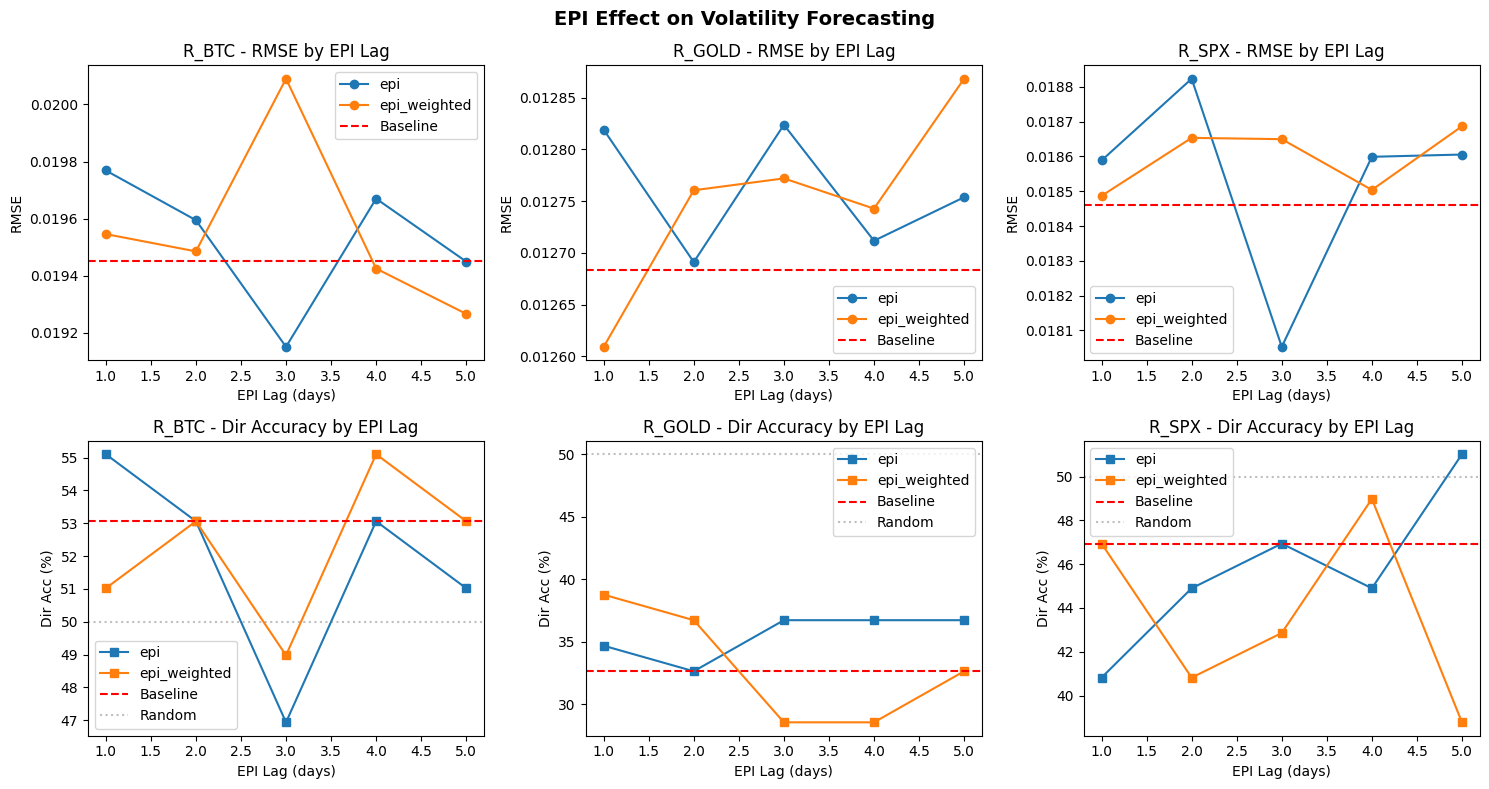

In [15]:
# ============================================================
# 7b. Visualization: EPI Effect on Volatility
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Top row: RMSE by lag
for i, asset in enumerate(assets):
    ax = axes[0, i]
    for epi_type in ["epi", "epi_weighted"]:
        subset = arx_vol_df[(arx_vol_df["asset"] == asset) & (arx_vol_df["epi_type"] == epi_type)]
        ax.plot(subset["epi_lag"], subset["rmse"], marker='o', label=epi_type)
    
    # Baseline
    baseline_rmse = baseline_vol_results.get(asset, {}).get("rmse", 0)
    ax.axhline(y=baseline_rmse, color='red', linestyle='--', label='Baseline')
    
    ax.set_title(f"{asset.upper()} - RMSE by EPI Lag")
    ax.set_xlabel("EPI Lag (days)")
    ax.set_ylabel("RMSE")
    ax.legend()

# Bottom row: Dir Acc by lag
for i, asset in enumerate(assets):
    ax = axes[1, i]
    for epi_type in ["epi", "epi_weighted"]:
        subset = arx_vol_df[(arx_vol_df["asset"] == asset) & (arx_vol_df["epi_type"] == epi_type)]
        ax.plot(subset["epi_lag"], subset["dir_acc"], marker='s', label=epi_type)
    
    # Baseline
    baseline_dir = baseline_vol_results.get(asset, {}).get("dir_acc", 50)
    ax.axhline(y=baseline_dir, color='red', linestyle='--', label='Baseline')
    ax.axhline(y=50, color='gray', linestyle=':', alpha=0.5, label='Random')
    
    ax.set_title(f"{asset.upper()} - Dir Accuracy by EPI Lag")
    ax.set_xlabel("EPI Lag (days)")
    ax.set_ylabel("Dir Acc (%)")
    ax.legend()

plt.suptitle("EPI Effect on Volatility Forecasting", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Conclusions

### Summary
This notebook tested whether EPI (Emotional Polarity Index) from YouTube financial commentary can predict asset return volatility.

### Key Questions Answered:
1. **Does EPI correlate with volatility?** Check the correlation analysis in Section 4.
2. **Does EPI Granger-cause volatility?** Check the Granger tests in Section 4b.
3. **Can EPI improve volatility forecasts?** Compare ARX models with/without EPI in Section 5.
4. **What's the optimal EPI lag for volatility?** See Section 5c for best lags.
5. **Does EPI help in GARCH models?** Check GARCH-X results in Section 6.

### Interpretation Guidelines:
- **Positive EPI coefficient**: Higher emotional intensity → Higher future volatility
- **Negative EPI coefficient**: Higher emotional intensity → Lower future volatility (contrarian signal)
- **Significant at lags 1-2**: Immediate sentiment-volatility link
- **Significant at lags 3-5**: Delayed sentiment processing by markets